In [ ]:
import yfinance as yf
import pandas as pd

# หุ้น
tickers = ["KTB.BK", "KKP.BK"]

# โหลดข้อมูล
data = yf.download(tickers, start="2020-01-01", end="2025-01-01")

# เอาราคาปิด
close = data["Close"]
close.columns = ["KTB", "KKP"]

print(close.head())

/tmp/ipykernel_22496/2383137525.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  2 of 2 completed

                  KTB        KKP
Date                            
2020-01-02  46.919037  11.594709
2020-01-03  47.619316  11.594709
2020-01-06  46.568893  11.455852
2020-01-07  46.919037  11.386420
2020-01-08  46.743958  11.178133


In [ ]:
#คำนวน return
returns = close.pct_change().dropna()
print(returns.head())

                 KTB       KKP
Date                          
2020-01-03  0.014925  0.000000
2020-01-06 -0.022059 -0.011976
2020-01-07  0.007519 -0.006061
2020-01-08 -0.003732 -0.018293
2020-01-09  0.003745  0.000000


In [ ]:
#คำนวน Risk + Return
import numpy as np

# annualized
mean_returns = returns.mean() * 252
volatility = returns.std() * np.sqrt(252)

print("Return:\n", mean_returns)
print("Risk:\n", volatility)

Return:
 KTB    0.049069
KKP    0.129656
dtype: float64
Risk:
 KTB    0.289920
KKP    0.273872
dtype: float64


In [ ]:
# Sharp Ratio
risk_free_rate = 0.02

sharpe = (mean_returns - risk_free_rate) / volatility
print("Sharpe Ratio:\n", sharpe)

Sharpe Ratio:
 KTB    0.100265
KKP    0.400393
dtype: float64


In [ ]:
#สร้าง Portfolio
weights = [0.5, 0.5]

portfolio_return = returns.dot(weights)

portfolio_mean = portfolio_return.mean() * 252
portfolio_vol = portfolio_return.std() * np.sqrt(252)

print("Portfolio Return:", portfolio_mean)
print("Portfolio Risk:", portfolio_vol)


Portfolio Return: 0.08936251627755079
Portfolio Risk: 0.24701909021801363


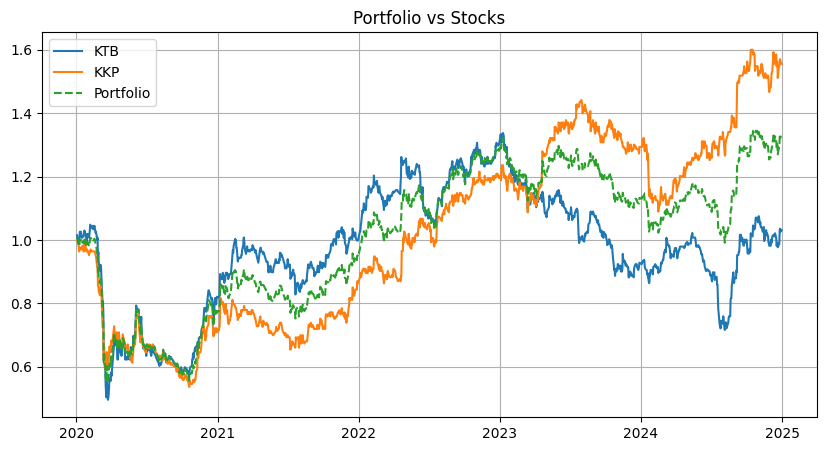

In [ ]:
#วาดกราฟ
import matplotlib.pyplot as plt

# cumulative return
cum_returns = (1 + returns).cumprod()
portfolio_cum = (1 + portfolio_return).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_returns["KTB"], label="KTB")
plt.plot(cum_returns["KKP"], label="KKP")
plt.plot(portfolio_cum, label="Portfolio", linestyle="--")

plt.legend()
plt.title("Portfolio vs Stocks")
plt.grid()
plt.show()